In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import xgboost as xgb

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV
)

In [2]:
file_path_1 = r"D:\Singapore\Alzheimer\R files\final data_new\imoutations_diff_ks\final_data_imputed_k1.csv"
df = pd.read_csv(file_path_1)

In [3]:
file_path =  r"D:\Singapore\Alzheimer\R files\final data_new\Variable list-11MAY2025.xlsx"
df_Variables = pd.read_excel(file_path)

In [4]:
# Group features based on the "Group" column
demographics = df_Variables[df_Variables['Group'] == 'Demographic']['Predictor'].tolist()
clinical_cognitive = df_Variables[df_Variables['Group'] == 'Clinical/Cognitive']['Predictor'].tolist()
biomarker = df_Variables[df_Variables['Group'] == 'Biomarker']['Predictor'].tolist()
neuroimaging = df_Variables[df_Variables['Group'] == 'Neuroimaging']['Predictor'].tolist()

# Optional: Print or check lists
print("Demographics:", demographics)
print("Clinical/Cognitive:", clinical_cognitive)
print("Biomarker:", biomarker)
print("Neuroimaging:", neuroimaging)

Demographics: ['AGE', 'PTGENDER', 'PTEDUCAT', 'PTRACCAT', 'PTMARRY']
Clinical/Cognitive: ['CDRSB', 'ADAS11', 'ADAS13', 'ADASQ4', 'RAVLT.immediate', 'RAVLT.learning', 'RAVLT.forgetting', 'RAVLT.perc.forgetting', 'LDELTOTAL', 'TRABSCOR', 'FAQ', 'EcogPtTotal', 'MOCA_bl', 'MMSE_bl']
Biomarker: ['FDG', 'AV45', 'ABETA', 'TAU', 'PTAU']
Neuroimaging: ['Ventricles', 'Hippocampus', 'WholeBrain', 'Entorhinal', 'Fusiform', 'MidTemp', 'ICV']


In [5]:
fig_save_dir = r"D:\Singapore\Alzheimer\R files\final data_new\figures\shap"
os.makedirs(fig_save_dir, exist_ok=True)

In [6]:
group_1 = demographics + clinical_cognitive
group_2 = demographics + biomarker
group_3 = demographics + clinical_cognitive + biomarker
group_4 = neuroimaging

In [7]:
synthetic_data_1 = pd.read_csv(
    r"D:\Singapore\Alzheimer\R files\final data_new\synthetic_data\TVAE\group_1_3\synthetic_group_1_TVAE_3x.csv"
)


synthetic_data_2 = pd.read_csv(
    r"D:\Singapore\Alzheimer\R files\final data_new\synthetic_data\TVAE\group_2\synthetic_group_2_TVAE_3x.csv"
)


synthetic_data_3 = pd.read_csv(
    r"D:\Singapore\Alzheimer\R files\final data_new\synthetic_data\TVAE\group_1_3\synthetic_group_3_TVAE_3x.csv"
)


synthetic_data_4 = pd.read_csv(
    r"D:\Singapore\Alzheimer\R files\final data_new\synthetic_data\TVAE\group_4\synthetic_group_4_TVAE_3x.csv"
)

In [8]:
target_col = "convert_Within_3Years"



real_data_group = pd.concat(
    [df[group_3], df[target_col]],
    axis=1
)

train_data, test_data = train_test_split(
    real_data_group,
    test_size=0.30,
    random_state=100,
    stratify=real_data_group[target_col]
)

augmented_train = pd.concat(
    [train_data, synthetic_data_3],
    ignore_index=True
)

X_train_aug = augmented_train[group_3]
y_train_aug = augmented_train[target_col]

X_test = test_data[group_3]
y_test = test_data[target_col]

In [9]:
neg_count = (y_train_aug==0).sum()
pos_count = (y_train_aug==1).sum()

scale_pos_weight = neg_count / pos_count

model = xgb.XGBClassifier(
    eval_metric='logloss',
    random_state=100,
    scale_pos_weight=scale_pos_weight
)

param_dist = {

    'n_estimators':[100, 200, 300],
    'max_depth':[2, 3, 4, 5],
    'learning_rate':[0.01, 0.05, 0.1],
    'min_child_weight':[1, 3, 5],
    'subsample':[0.6, 0.8, 1],
    'colsample_bytree':[0.6, 0.8, 1],
    'gamma':[0, 0.1, 0.3],
    'reg_alpha':[0, 0.5, 1],
    'reg_lambda':[1, 2, 5]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=100
)

search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    cv=cv,
    scoring='roc_auc',
    refit=True,
    random_state=100
)

search.fit(
    X_train_aug,
    y_train_aug
)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...tate=100, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [2, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here

In [10]:
best_params = search.best_params_

best_model = xgb.XGBClassifier(

    **best_params,

    #eval_metric='logloss',

    random_state=100,

    scale_pos_weight=scale_pos_weight
)

best_model.fit(
    X_train_aug,
    y_train_aug
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


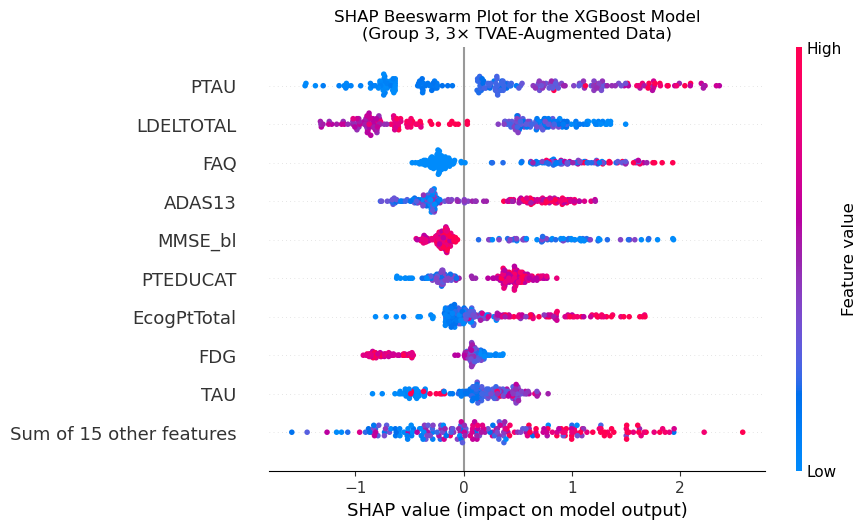

In [11]:
explainer = shap.Explainer(
    best_model,
    X_train_aug
)

shap_values = explainer(
    X_test
)

shap.plots.beeswarm(
    shap_values,
    show=False
)

plt.title(
    "SHAP Beeswarm Plot for the XGBoost Model\n(Group 3, 3× TVAE-Augmented Data)")

plt.savefig(os.path.join(fig_save_dir, f"Beeswarm_Group 3_Real_TVAE_xgb.pdf"), dpi=600, bbox_inches="tight")
plt.show()

In [12]:
y_pred = best_model.predict(X_test)

In [13]:
tp_idx_TP = np.where(
    (y_test==1) &
    (y_pred==1)
)[0][0]

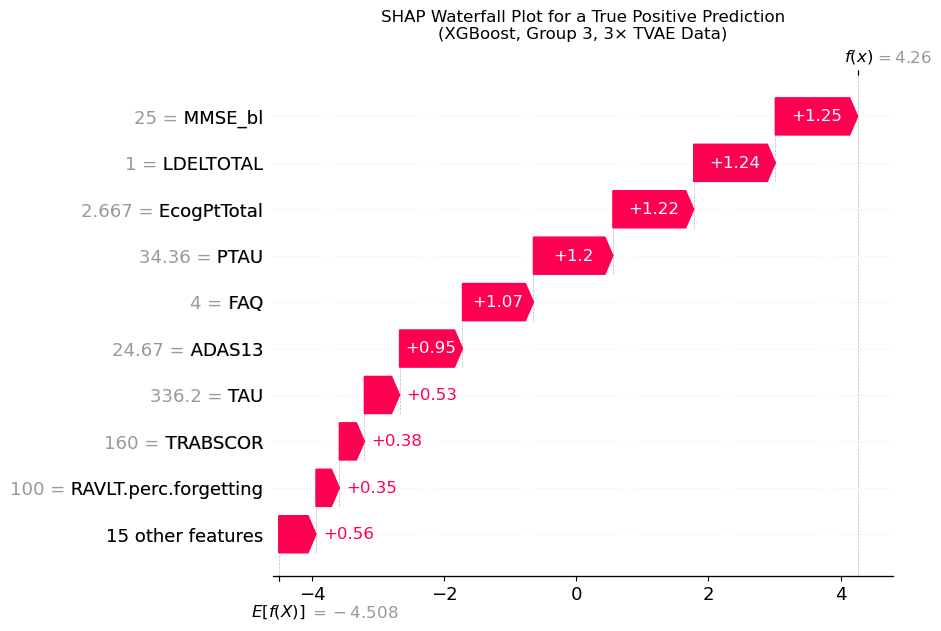

In [14]:
shap.plots.waterfall(
    shap_values[tp_idx_TP],
    show = False
)
plt.title("SHAP Waterfall Plot for a True Positive Prediction\n(XGBoost, Group 3, 3× TVAE Data)")
plt.savefig(os.path.join(fig_save_dir, f"waterfall_TP_Group 3_Real_TVAE.pdf"), dpi=600, bbox_inches="tight")          
plt.show()          

In [15]:
tp_idx_TN = np.where(
    (y_test==0) &
    (y_pred==0)
)[0][0]

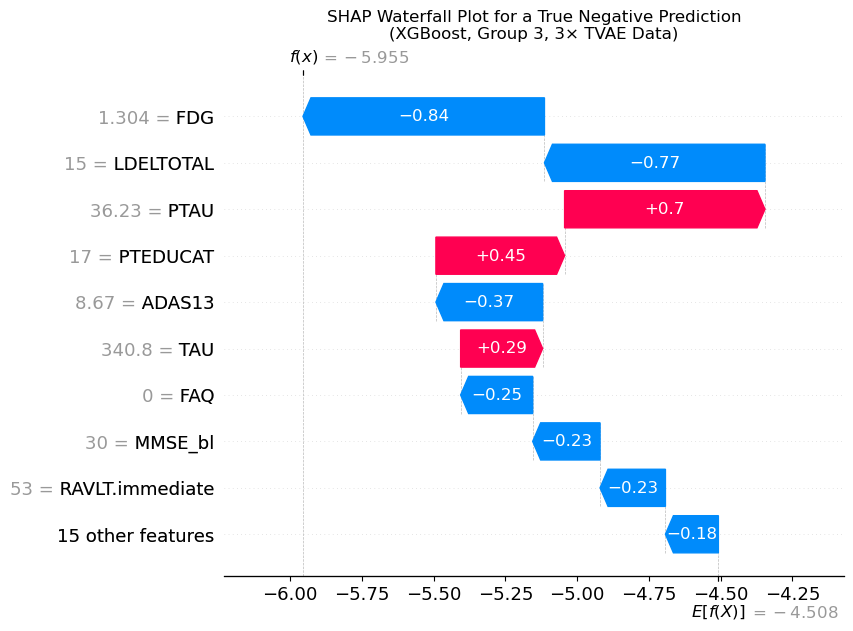

In [16]:
shap.plots.waterfall(
    shap_values[tp_idx_TN],
    show = False
)
plt.title("SHAP Waterfall Plot for a True Negative Prediction\n(XGBoost, Group 3, 3× TVAE Data)")
plt.savefig(os.path.join(fig_save_dir, f"waterfall_TN_Group 3_Real_TVAE.pdf"), dpi=600, bbox_inches="tight")          
plt.show()  

In [17]:
tp_idx_FN = np.where(
    (y_test==1) &
    (y_pred==0)
)[0][0]

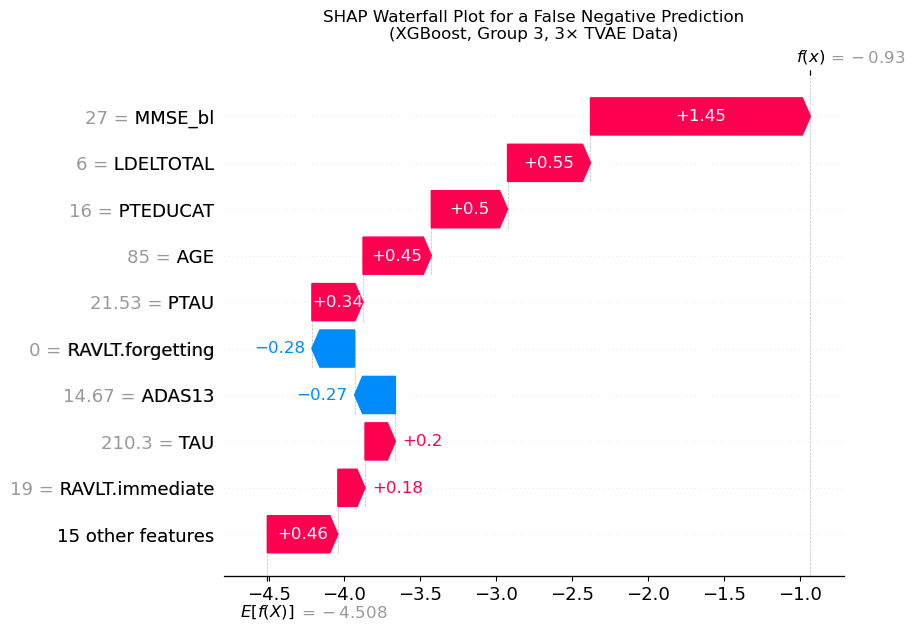

In [18]:
shap.plots.waterfall(
    shap_values[tp_idx_FN],
    show = False
)
plt.title("SHAP Waterfall Plot for a False Negative Prediction\n(XGBoost, Group 3, 3× TVAE Data)")
plt.savefig(os.path.join(fig_save_dir, f"waterfall_FN_Group 3_Real_TVAE.pdf"), dpi=600, bbox_inches="tight")          
plt.show()  

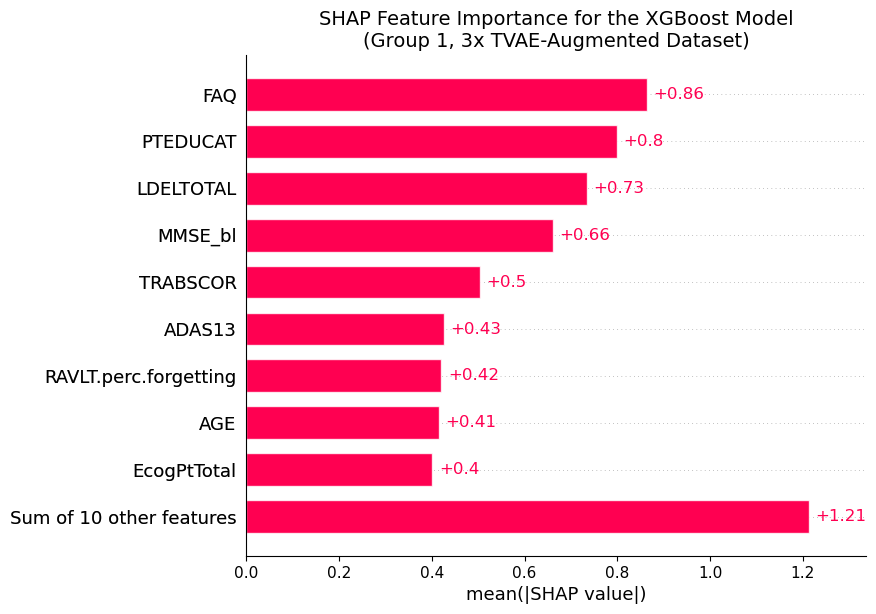

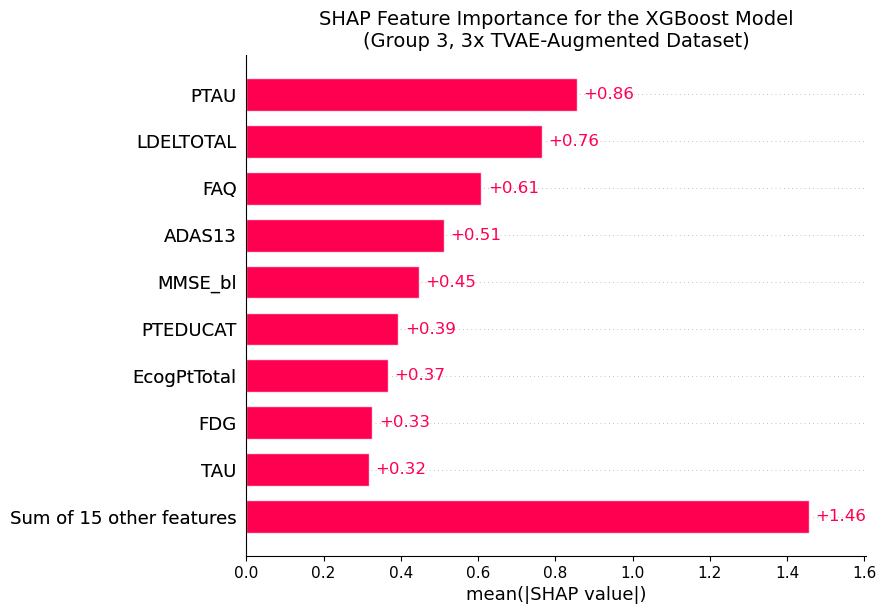

In [22]:
target_col = "convert_Within_3Years"

for group, synthetic_data in zip(
    [group_1, group_3],
    [synthetic_data_1, synthetic_data_3]
):
    real_data_group = pd.concat(
    [df[group], df[target_col]],
    axis=1
)

    train_data, test_data = train_test_split(
        real_data_group,
        test_size=0.30,
        random_state=100,
        stratify=real_data_group[target_col])

    augmented_train = pd.concat(
        [train_data, synthetic_data],
        ignore_index=True)

    X_train_aug = augmented_train[group]
    y_train_aug = augmented_train[target_col]

    X_test = test_data[group]
    y_test = test_data[target_col]

    neg_count = (y_train_aug==0).sum()
    pos_count = (y_train_aug==1).sum()

    scale_pos_weight = neg_count / pos_count

    model = xgb.XGBClassifier(
        eval_metric='logloss',
        random_state=100,
        scale_pos_weight=scale_pos_weight)

    param_dist = {
        'n_estimators':[100, 200, 300],
        'max_depth':[2, 3, 4, 5],
        'learning_rate':[0.01, 0.05, 0.1],
        'min_child_weight':[1, 3, 5],
        'subsample':[0.6, 0.8, 1],
        'colsample_bytree':[0.6, 0.8, 1],
        'gamma':[0, 0.1, 0.3],
        'reg_alpha':[0, 0.5, 1],
        'reg_lambda':[1, 2, 5]}

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=100)

    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_dist,
        cv=cv,
        scoring='roc_auc',
        refit=True,
        random_state=100)

    search.fit(
        X_train_aug,
        y_train_aug)
    best_params = search.best_params_

    best_model = xgb.XGBClassifier(
        **best_params,
        eval_metric='logloss',
        random_state=100,
        scale_pos_weight=scale_pos_weight)

    best_model.fit(
        X_train_aug,
        y_train_aug)
    
    explainer = shap.Explainer(
        best_model,
        X_train_aug)


    shap_values = explainer(X_test)

    shap.plots.bar(
        shap_values,
        show = False)




    
    plt.title("SHAP Feature Importance for the XGBoost Model\n"f"(Group {1 if group == group_1 else 3}, 3x TVAE-Augmented Dataset)",
             fontsize=14)
    plt.savefig(os.path.join(fig_save_dir, f"feature_importance_Group{1 if group==group_1 else 3}_Real_TVAE.pdf"), dpi=600, bbox_inches="tight")          
    plt.show()  

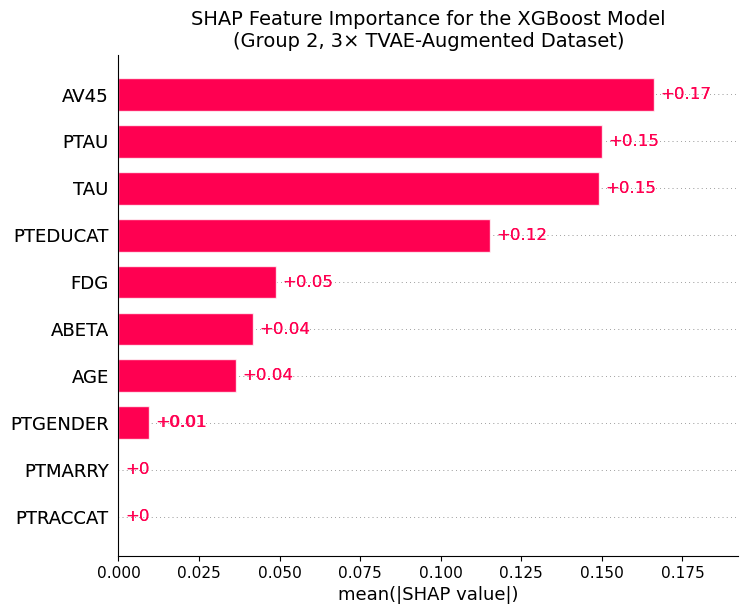

In [23]:
target_col = "convert_Within_3Years"

real_data_group = pd.concat(
    [df[group_2], df[target_col]],
    axis=1
)

train_data, test_data = train_test_split(
    real_data_group,
    test_size=0.30,
    random_state=100,
    stratify=real_data_group[target_col])

augmented_train = pd.concat(
        [train_data, synthetic_data_2],
        ignore_index=True)

X_train_aug = augmented_train[group_2]
y_train_aug = augmented_train[target_col]

X_test = test_data[group_2]
y_test = test_data[target_col]

neg_count = (y_train_aug==0).sum()
pos_count = (y_train_aug==1).sum()

scale_pos_weight = neg_count / pos_count

model = xgb.XGBClassifier(
    eval_metric='logloss',
    random_state=100,
    scale_pos_weight=scale_pos_weight)

param_dist = {
    'n_estimators':[50],
    'max_depth':[2, 3, 4],
    'learning_rate':[0.01, 0.02],
    'subsample':[0.6, 0.7, 0.8],
    'colsample_bytree':[0.5, 0.7, 0.9, 1],
    'gamma':[0, 0.25, 0.5],
    'reg_alpha':[0, 0.1, 1.0],
    'reg_lambda':[1, 1.5, 2]}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=100)

search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    cv=cv,
    scoring='roc_auc',
    refit=True,
    random_state=100)

search.fit(
    X_train_aug,
    y_train_aug)

best_params = search.best_params_

best_model = xgb.XGBClassifier(
    **best_params,
    eval_metric='logloss',
    random_state=100,
    scale_pos_weight=scale_pos_weight)

best_model.fit(
    X_train_aug,
    y_train_aug)
    
explainer = shap.Explainer(
    best_model,
    X_train_aug)

shap_values = explainer(X_test)

shap.plots.bar(
        shap_values, show = False)

 
shap.plots.bar(
        shap_values,
        show = False)

 
plt.title(
    "SHAP Feature Importance for the XGBoost Model\n(Group 2, 3× TVAE-Augmented Dataset)",
    fontsize=14
)

plt.savefig(
    os.path.join(fig_save_dir, "feature_importance_Group2_Real_TVAE.pdf"),
    dpi=600,
    bbox_inches='tight')

plt.show()

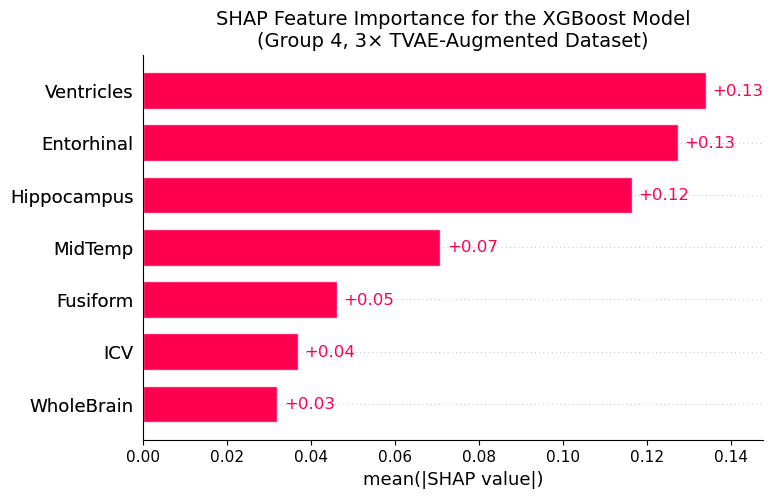

In [24]:
target_col = "convert_Within_3Years"

real_data_group = pd.concat(
    [df[group_4], df[target_col]],
    axis=1
)

train_data, test_data = train_test_split(
    real_data_group,
    test_size=0.30,
    random_state=100,
    stratify=real_data_group[target_col])

augmented_train = pd.concat(
        [train_data, synthetic_data_4],
        ignore_index=True)

X_train_aug = augmented_train[group_4]
y_train_aug = augmented_train[target_col]

X_test = test_data[group_4]
y_test = test_data[target_col]

neg_count = (y_train_aug==0).sum()
pos_count = (y_train_aug==1).sum()

scale_pos_weight = neg_count / pos_count

model = xgb.XGBClassifier(
    eval_metric='logloss',
    random_state=100,
    scale_pos_weight=scale_pos_weight)

param_dist = {
    'n_estimators':[50],
    'max_depth':[2, 3, 4],
    'learning_rate':[0.01, 0.02],
    'subsample':[0.6, 0.7, 0.8],
    'colsample_bytree':[0.5, 0.7, 0.9, 1],
    'gamma':[0, 0.25, 0.5],
    'reg_alpha':[0, 0.1, 1.0],
    'reg_lambda':[1, 1.5, 2]}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=100)

search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    cv=cv,
    scoring='roc_auc',
    refit=True,
    random_state=100)

search.fit(
    X_train_aug,
    y_train_aug)

best_params = search.best_params_

best_model = xgb.XGBClassifier(
    **best_params,
    eval_metric='logloss',
    random_state=100,
    scale_pos_weight=scale_pos_weight)

best_model.fit(
    X_train_aug,
    y_train_aug)
    
explainer = shap.Explainer(
    best_model,
    X_train_aug)

shap_values = explainer(X_test)

shap.plots.bar(
        shap_values,
        show = False)

 
plt.title(
    "SHAP Feature Importance for the XGBoost Model\n(Group 4, 3× TVAE-Augmented Dataset)",
    fontsize=14
)

plt.savefig(
    os.path.join(fig_save_dir, "feature_importance_Group4_Real_TVAE.pdf"),
    dpi=600,
    bbox_inches='tight')

plt.show()